# Malmö urban consumption gap: reproducible scenario model

**Companion notebook for:** *Beyond the Footprint: the urban consumption gap, sufficiency and the limits of hotspot strategies in city climate governance.* Submitted to *Sustainable Production and Consumption*.

This notebook reproduces the scenario calculations, sensitivity analysis and manuscript figures for the Malmö urban consumption gap study. It loads the cleaned CSV files in `data/`, which were extracted from the original Scenario Analyzer workbook by `scripts/extract_clean_dataset_from_workbook.py`.

The notebook is designed for transparency rather than prediction. It implements a deterministic stress-test framework: scenario outputs are exact functions of stated inputs, making them legible to municipal users, reviewers and other researchers. Scenario 4 is a target-seeking coordinated transition pathway, not a forecast.

## 1. Load packages and cleaned data

In [1]:
from pathlib import Path
import math
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if not (ROOT / 'data').exists():
    raise FileNotFoundError('Run this notebook from the package root or from the notebooks/ folder.')

DATA_DIR = ROOT / 'data'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

baseline = pd.read_csv(DATA_DIR / 'baseline_categories.csv')
params = pd.read_csv(DATA_DIR / 'scenario_parameters.csv')
scenario_results_reference = pd.read_csv(DATA_DIR / 'scenario_results.csv')
scenario_summary = pd.read_csv(DATA_DIR / 'scenario_summary.csv')
sensitivity_reference = pd.read_csv(DATA_DIR / 'sensitivity_results.csv')
validation_summary = pd.read_csv(DATA_DIR / 'validation_summary.csv')

YEARS = list(range(2026, 2051))
TARGET_2030 = 3.1
TARGET_2050 = 1.0
MODEL_START_YEAR = 2026
BASELINE_TOTAL_T = baseline['baseline_kgco2e_per_capita'].sum() / 1000

print(f'Baseline total: {BASELINE_TOTAL_T:.3f} t CO₂e/capita/year')
print(f'Categories: {len(baseline)} ({baseline["is_placeholder"].sum()} placeholders)')
print(f'Positive-emission categories: {(baseline["baseline_kgco2e_per_capita"] > 0).sum()}')

Baseline total: 5.735 t CO₂e/capita/year
Categories: 111 (1 placeholders)
Positive-emission categories: 110


## 2. Model equations

The model applies a logistic adoption curve (Eq. 2 in the article) to each active category and combines behavioural and technological reduction potentials multiplicatively (Eq. 3). Categories that are not active in a scenario remain at baseline level. Infrastructure is represented through the adoption parameters (L, k, t₀), not as a separate reduction lever.

**Key equations:**
- Adoption: A(y) = L / [1 + exp(-k · (y - t₀))]
- Combined reduction: R = 1 - (1 - R_tech)(1 - R_beh)
- Effective reduction: r(y) = R · A(y)
- Category emissions: E(y) = E₀ · [1 - r(y)]
- Urban consumption gap: G(y) = E_scenario(y) - T(y)

In [2]:
def target_pathway(year, target_2030=TARGET_2030, target_2050=TARGET_2050):
    if year <= 2030:
        return target_2030
    return target_2030 + (target_2050 - target_2030) * ((year - 2030) / (2050 - 2030))


def adoption_fraction(year, L, k, t0):
    return L / (1 + math.exp(-k * (year - t0)))


def combined_reduction(technical, behavioral):
    technical = 0.0 if pd.isna(technical) else float(technical)
    behavioral = 0.0 if pd.isna(behavioral) else float(behavioral)
    return 1 - (1 - technical) * (1 - behavioral)


def calculate_scenario(scenario_id, scenario_params, baseline_df):
    """Calculate annual emissions for one scenario across all categories and years."""
    annual_rows = []
    category_rows = []

    for year in YEARS:
        total_emissions = 0.0
        for _, bp in baseline_df.iterrows():
            cat_id = bp['category_id']
            baseline_kg = bp['baseline_kgco2e_per_capita']

            sp = scenario_params[scenario_params['category_id'] == cat_id]
            if sp.empty or sp.iloc[0]['combined_reduction_fraction'] == 0:
                emissions_kg = baseline_kg
            else:
                sp = sp.iloc[0]
                L = float(sp['L_max_adoption'])
                k = float(sp['k_adoption_speed'])
                t0 = float(sp['t0_inflection_year'])
                R = float(sp['combined_reduction_fraction'])
                A = adoption_fraction(year, L, k, t0)
                emissions_kg = baseline_kg * (1 - R * A)

            reduction_kg = baseline_kg - emissions_kg
            total_emissions += emissions_kg

            category_rows.append({
                'scenario_id': scenario_id,
                'year': year,
                'category_id': cat_id,
                'category': bp['category'],
                'domain': bp['domain'],
                'baseline_kgco2e_per_capita': baseline_kg,
                'emissions_kgco2e_per_capita': emissions_kg,
                'reduction_kgco2e_per_capita': reduction_kg,
            })

        total_t = total_emissions / 1000
        target_t = target_pathway(year)
        annual_rows.append({
            'scenario_id': scenario_id,
            'scenario_name': scenario_params.iloc[0]['scenario_name'],
            'year': year,
            'emissions_tco2e_per_capita': total_t,
            'target_tco2e_per_capita': target_t,
            'gap_tco2e_per_capita': total_t - target_t,
        })

    return pd.DataFrame(annual_rows), pd.DataFrame(category_rows)

## 3. Recalculate scenario pathways and validate against cleaned outputs

In [3]:
annual_frames = []
category_frames = []
for scenario_id, scenario_params_group in params.groupby('scenario_id'):
    annual, category = calculate_scenario(scenario_id, scenario_params_group, baseline)
    annual_frames.append(annual)
    category_frames.append(category)

scenario_results = pd.concat(annual_frames, ignore_index=True)
category_results = pd.concat(category_frames, ignore_index=True)

merged = scenario_results.merge(
    scenario_results_reference,
    on=['scenario_id', 'year'],
    suffixes=('_notebook', '_reference')
)
merged['abs_diff'] = (merged['emissions_tco2e_per_capita_notebook'] - merged['emissions_tco2e_per_capita_reference']).abs()

print('Validation: max absolute difference per scenario (t CO₂e/capita):')
print(merged.groupby('scenario_id')['abs_diff'].max().to_string())
print(f'\nOverall max difference: {merged["abs_diff"].max():.2e}')
assert merged['abs_diff'].max() < 1e-10, 'Validation failed: notebook results do not match reference.'
print('\n✓ All scenarios validated successfully.')

Validation: max absolute difference per scenario (t CO₂e/capita):
scenario_id
S1    0.000000e+00
S2    0.000000e+00
S3    4.440892e-16
S4    4.440892e-16

Overall max difference: 4.44e-16

✓ All scenarios validated successfully.


## 4. Scenario summary

The four scenarios differ in coverage (share of baseline addressed), depth (reduction potentials) and adoption dynamics. Scenario 4 is the only pathway that approaches the 1.0 t CO₂e target.

In [4]:
display_cols = [
    'scenario_id', 'scenario_name', 'transition_logic', 'active_categories',
    'active_baseline_coverage_pct', 'emissions_2030_tco2e_per_capita',
    'emissions_2050_tco2e_per_capita', 'gap_2050_tco2e_per_capita'
]
scenario_summary[display_cols].round(3)

,scenario_id,scenario_name,transition_logic,active_categories,active_baseline_coverage_pct,emissions_2030_tco2e_per_capita,emissions_2050_tco2e_per_capita,gap_2050_tco2e_per_capita
0,S1,Scenario 1,Limited change / static reference,0,0.000,5.735,5.735,4.735
1,S2,Scenario 2,Major-emission-category focus,9,45.045,5.252,4.097,3.097
2,S3,Scenario 3,Lifestyle-centred transition,31,71.417,4.370,3.008,2.008
3,S4,Scenario 4,Coordinated target-seeking transition,109,99.999,3.200,1.060,0.060


## 5. Figures

In [5]:
# Consistent colour palette and style
DOMAIN_ORDER = [
    'Food and drink', 'Housing', 'Local transport', 'Flights',
    'Other consumption', 'Leisure, sport and culture', 'Clothing and shoes',
]

DOMAIN_COLORS = {
    'Food and drink': '#6C9A73',
    'Housing': '#4C78A8',
    'Local transport': '#F58518',
    'Flights': '#B279A2',
    'Other consumption': '#8E6C4A',
    'Leisure, sport and culture': '#72B7B2',
    'Clothing and shoes': '#E45756',
    'Carbon capture placeholder': '#9A9A9A',
}

SCENARIO_COLORS = {'S1': '#9A9A9A', 'S2': '#4C78A8', 'S3': '#F58518', 'S4': '#54A24B'}
SCENARIO_LABELS = {
    'S1': 'S1: Limited change',
    'S2': 'S2: Hotspot focus',
    'S3': 'S3: Lifestyle-centred',
    'S4': 'S4: Coordinated transition',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'grid.alpha': 0.25,
})

### Figure 1. Urban consumption gap framework (conceptual schematic)

This is a schematic conceptual figure for Section 2.2. It illustrates the three components of the urban consumption gap: the current trajectory (limited change), the best feasible coordinated transition pathway, and the target-compatible pathway. The red zone between the coordinated pathway and the target is the residual urban consumption gap. The green zone is the modelled transition potential. Y-axis ticks are deliberately omitted because the figure is conceptual, not data-driven.

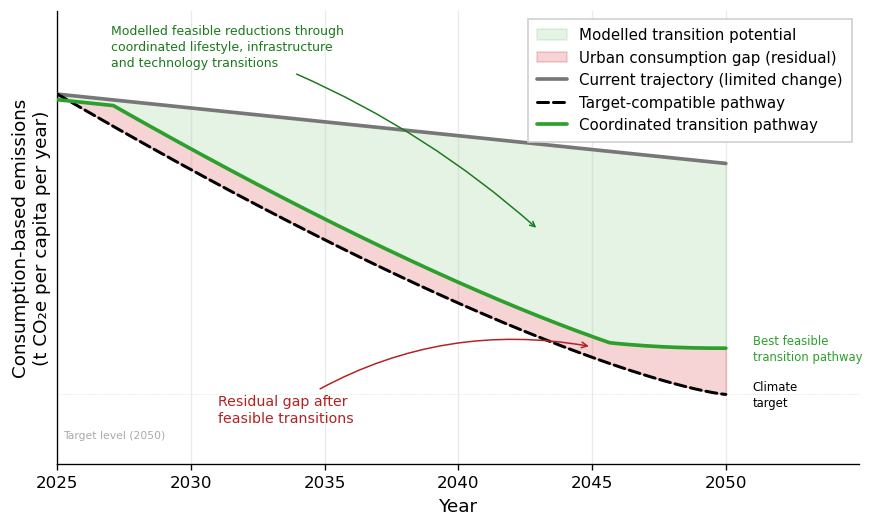

In [6]:
# Figure 1: conceptual urban consumption gap (schematic)
years_f1 = np.linspace(2025, 2050, 300)
t = (years_f1 - 2025) / 25
y0 = 8.0

current = y0 - 1.5 * t
target_f1 = y0 - (y0 - 1.5) * (1 - (1 - t)**1.3)
coordinated = y0 - (y0 - 2.5) * (1 - (1 - t)**2.2)
coordinated = np.clip(coordinated, target_f1 + 0.45, current - 0.12)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Shaded zones
ax.fill_between(years_f1, coordinated, current,
                alpha=0.12, color='#2ca02c', label='Modelled transition potential', zorder=1)
ax.fill_between(years_f1, target_f1, coordinated,
                alpha=0.20, color='#d62728', label='Urban consumption gap (residual)', zorder=2)

# Lines
ax.plot(years_f1, current, color='#777777', linewidth=2.2, solid_capstyle='round',
        label='Current trajectory (limited change)', zorder=3)
ax.plot(years_f1, target_f1, color='black', linewidth=1.8, linestyle='--',
        dash_capstyle='round', label='Target-compatible pathway', zorder=4)
ax.plot(years_f1, coordinated, color='#2ca02c', linewidth=2.2, solid_capstyle='round',
        label='Coordinated transition pathway', zorder=5)

# Right-side labels
rx = 2051
ax.text(rx, coordinated[-1], 'Best feasible\ntransition pathway',
        va='center', ha='left', fontsize=7, color='#2ca02c', linespacing=1.3)
ax.text(rx, target_f1[-1], 'Climate\ntarget',
        va='center', ha='left', fontsize=7, color='black', linespacing=1.3)

# Gap annotation
gap_yr = 2045
idx = np.argmin(np.abs(years_f1 - gap_yr))
gap_mid = (coordinated[idx] + target_f1[idx]) / 2
ax.annotate('Residual gap after\nfeasible transitions',
            xy=(gap_yr, gap_mid), xytext=(2031, 0.9),
            fontsize=8.5, color='#b22222', ha='left', linespacing=1.3,
            arrowprops=dict(arrowstyle='->', color='#b22222', lw=0.9,
                            connectionstyle='arc3,rad=-0.2'), zorder=6)

# Transition potential annotation
tp_yr = 2043
idx2 = np.argmin(np.abs(years_f1 - tp_yr))
tp_mid = (current[idx2] + coordinated[idx2]) / 2
ax.annotate('Modelled feasible reductions through\ncoordinated lifestyle, infrastructure\nand technology transitions',
            xy=(tp_yr, tp_mid), xytext=(2027, 8.6),
            fontsize=7.5, color='#1a7a1a', ha='left', linespacing=1.3,
            arrowprops=dict(arrowstyle='->', color='#1a7a1a', lw=0.9,
                            connectionstyle='arc3,rad=-0.1'), zorder=6)

ax.set_xlim(2025, 2055)
ax.set_ylim(0, 9.8)
ax.set_xlabel('Year')
ax.set_ylabel('Consumption-based emissions\n(t CO₂e per capita per year)')
ax.set_yticks([])
ax.set_xticks([2025, 2030, 2035, 2040, 2045, 2050])
ax.axhline(1.5, color='#dddddd', linewidth=0.5, linestyle=':', zorder=0)
ax.text(2025.2, 0.55, 'Target level (2050)', fontsize=6.5, color='#aaaaaa')
ax.legend(loc='upper right', frameon=True, framealpha=0.94,
          edgecolor='#cccccc', fancybox=False, borderpad=0.6)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_urban_consumption_gap_framework.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'fig1_urban_consumption_gap_framework.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

### Figure 2. Malmö baseline consumption footprint

The baseline footprint of 5.735 t CO₂e per capita is distributed across many categories. Passenger flights lead (850 kg), followed by district heating (506), vehicle emissions (410) and meat (290). The long tail of medium-sized categories collectively accounts for roughly half of total emissions, which is why hotspot strategies alone cannot close the gap.

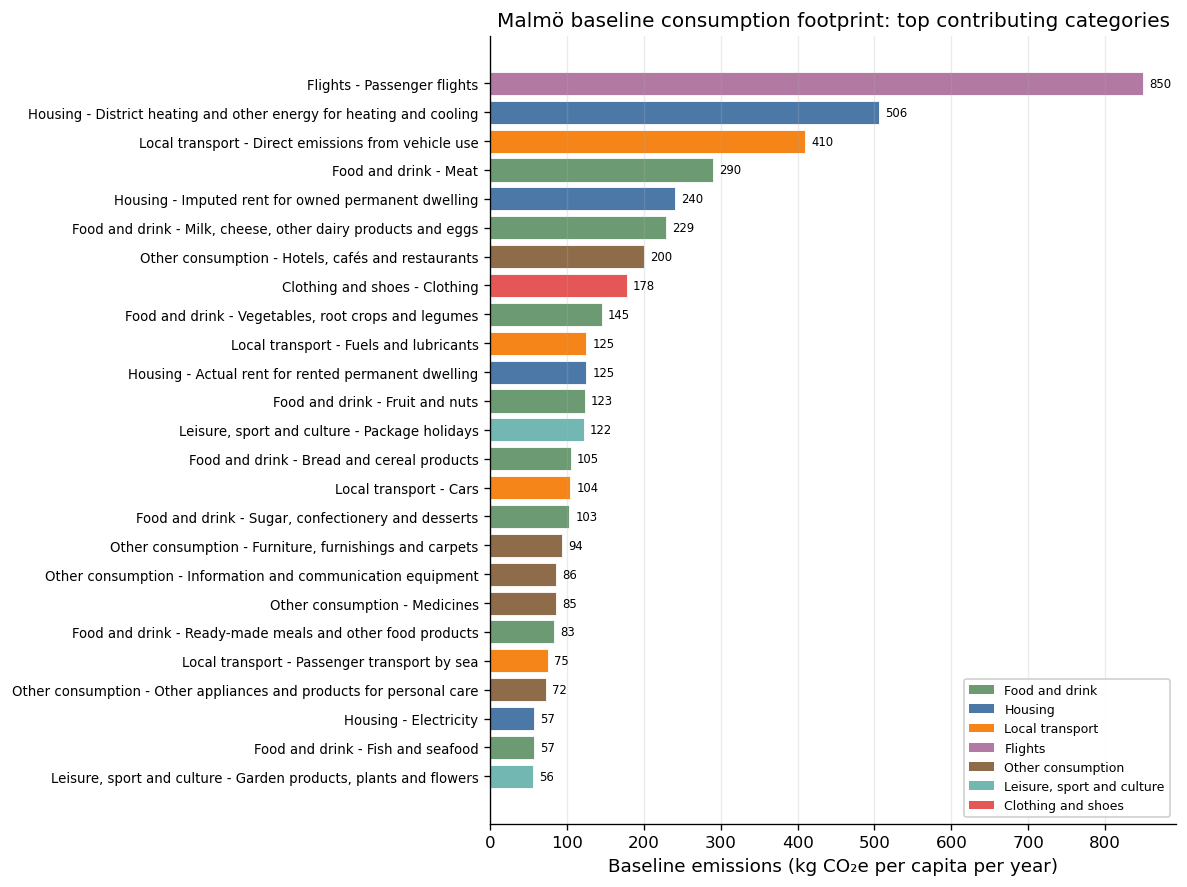

In [7]:
# Figure 2: baseline footprint, top 25 categories
plot_df = (baseline
    .query('is_placeholder == False')
    .sort_values('baseline_kgco2e_per_capita', ascending=False)
    .head(25)
    .iloc[::-1])

fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(plot_df))
colors = [DOMAIN_COLORS.get(d, '#999999') for d in plot_df['domain']]
ax.barh(y, plot_df['baseline_kgco2e_per_capita'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['category'], fontsize=8)
ax.set_xlabel('Baseline emissions (kg CO₂e per capita per year)')
ax.set_title("Malmö baseline consumption footprint: top contributing categories")
ax.grid(axis='x', alpha=0.25)
for i, v in enumerate(plot_df['baseline_kgco2e_per_capita']):
    ax.text(v + 8, i, f'{v:.0f}', va='center', fontsize=7)

# Domain legend
handles = [Patch(facecolor=DOMAIN_COLORS[d], label=d) for d in DOMAIN_ORDER]
ax.legend(handles=handles, loc='lower right', fontsize=7.5, framealpha=0.92, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_baseline_footprint_top_categories.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'fig2_baseline_footprint_top_categories.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

### Figure 3. Scenario pathways compared with the target pathway

The central results figure. Scenario 2 (hotspot focus) barely bends the curve. Scenario 3 (lifestyle-centred) achieves deeper reductions but plateaus well above the target. Only Scenario 4 (coordinated transition) converges with the 1.0 t target by 2050, and only under demanding assumptions tested in the sensitivity analysis.

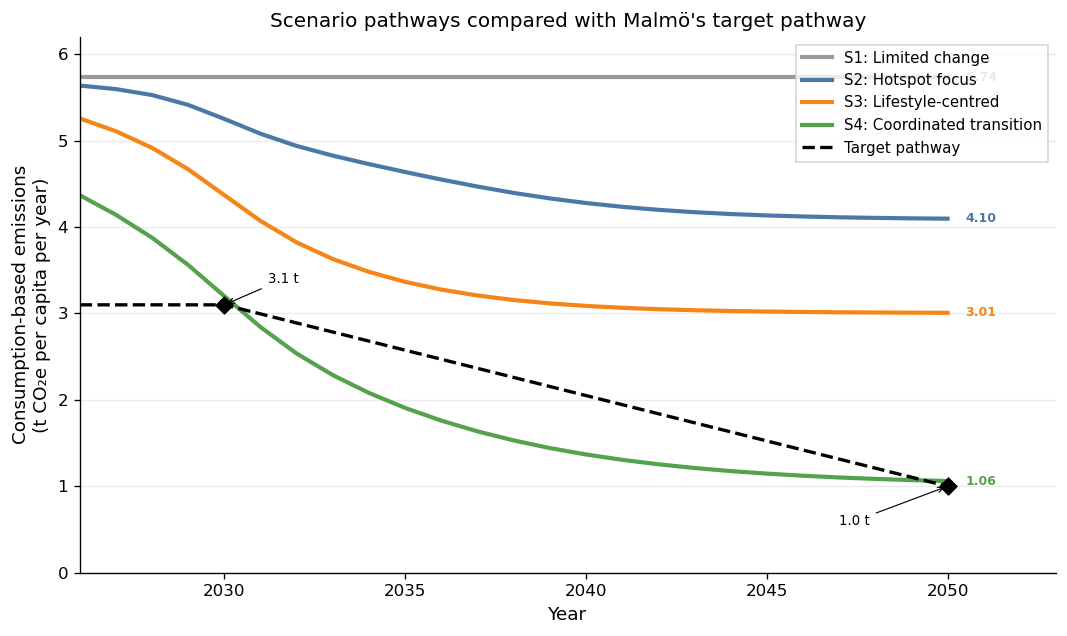

In [8]:
# Figure 3: scenario pathways with milestone markers and endpoint values
fig, ax = plt.subplots(figsize=(9, 5.4))

for sid in ['S1', 'S2', 'S3', 'S4']:
    sdf = scenario_results[scenario_results['scenario_id'] == sid]
    ax.plot(sdf['year'], sdf['emissions_tco2e_per_capita'],
            label=SCENARIO_LABELS[sid], color=SCENARIO_COLORS[sid], linewidth=2.5)

# Target pathway
target_years = np.arange(2026, 2051)
target_vals = np.where(target_years <= 2030, TARGET_2030,
              TARGET_2030 + (TARGET_2050 - TARGET_2030) * (target_years - 2030) / 20)
ax.plot(target_years, target_vals, linestyle='--', color='black', linewidth=2, label='Target pathway')

# 2030 and 2050 milestone markers
ax.scatter([2030], [TARGET_2030], color='black', s=50, zorder=5, marker='D')
ax.scatter([2050], [TARGET_2050], color='black', s=50, zorder=5, marker='D')
ax.annotate(f'{TARGET_2030} t', xy=(2030, TARGET_2030), xytext=(2031.2, TARGET_2030 + 0.25),
            fontsize=8, color='black', arrowprops=dict(arrowstyle='->', lw=0.7, color='black'))
ax.annotate(f'{TARGET_2050} t', xy=(2050, TARGET_2050), xytext=(2047, TARGET_2050 - 0.45),
            fontsize=8, color='black', arrowprops=dict(arrowstyle='->', lw=0.7, color='black'))

# Right-edge endpoint labels
for sid in ['S1', 'S2', 'S3', 'S4']:
    sdf = scenario_results[scenario_results['scenario_id'] == sid]
    y_end = sdf[sdf['year'] == 2050]['emissions_tco2e_per_capita'].values[0]
    ax.text(2050.5, y_end, f'{y_end:.2f}', va='center', fontsize=7.5,
            color=SCENARIO_COLORS[sid], fontweight='bold')

ax.set_ylim(0, 6.2)
ax.set_xlim(2026, 2053)
ax.set_xlabel('Year')
ax.set_ylabel('Consumption-based emissions\n(t CO₂e per capita per year)')
ax.set_title("Scenario pathways compared with Malmö's target pathway")
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=True, edgecolor='#cccccc', fancybox=False, loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_scenario_pathways_targets.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'fig3_scenario_pathways_targets.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

### Figure 4. Domain contributions to reductions in Scenario 4

Food and drink delivers the largest 2050 reduction (1.07 t), followed by housing (0.80), local transport and flights (0.79 each). No single domain closes the gap. Target consistency depends on distributed contributions from both large and medium-sized domains.

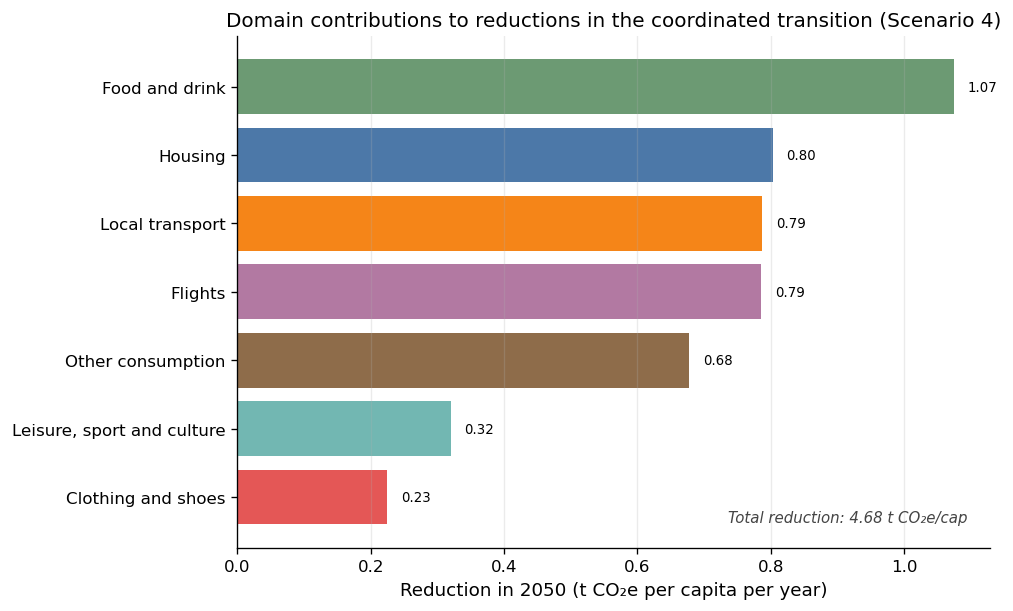

In [9]:
# Figure 4: domain contributions in Scenario 4, 2050
s4_2050 = category_results.query("scenario_id == 'S4' and year == 2050")
domain_df = (s4_2050.groupby('domain', as_index=False)
             .agg(reduction_tco2e_per_capita=('reduction_kgco2e_per_capita', lambda x: x.sum() / 1000))
             .query("domain != 'Carbon capture placeholder'")
             .sort_values('reduction_tco2e_per_capita'))

fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(domain_df))
colors = [DOMAIN_COLORS.get(d, '#999999') for d in domain_df['domain']]
ax.barh(y, domain_df['reduction_tco2e_per_capita'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(domain_df['domain'])
ax.set_xlabel('Reduction in 2050 (t CO₂e per capita per year)')
ax.set_title('Domain contributions to reductions in the coordinated transition (Scenario 4)')
ax.grid(axis='x', alpha=0.25)
for i, (_, r) in enumerate(domain_df.iterrows()):
    ax.text(r['reduction_tco2e_per_capita'] + 0.02, i,
            f"{r['reduction_tco2e_per_capita']:.2f}", va='center', fontsize=8)

# Total annotation
total = domain_df['reduction_tco2e_per_capita'].sum()
ax.text(0.97, 0.05, f'Total reduction: {total:.2f} t CO₂e/cap',
        transform=ax.transAxes, ha='right', fontsize=9, fontstyle='italic', color='#444444')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_domain_reduction_contributions_s4.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'fig4_domain_reduction_contributions_s4.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

## 6. Sensitivity analysis

The sensitivity table uses deterministic, one-at-a-time (OAT) variation around Scenario 4. This design identifies which individual assumptions most determine whether the gap can be closed. Adoption ceilings and technology assumptions are the most decisive parameters. Adoption timing has a smaller effect on 2050 outcomes but is critical for the 2030 milestone.

In [10]:
sensitivity_reference[['variant', 'parameter_group',
    'emissions_2030_tco2e_per_capita', 'emissions_2050_tco2e_per_capita',
    'delta_2050_vs_base_tco2e_per_capita']].round(3)

,variant,parameter_group,emissions_2030_tco2e_per_capita,emissions_2050_tco2e_per_capita,delta_2050_vs_base_tco2e_per_capita
0,Base Scenario 4,Base,3.200,1.060,0.000
1,All adoption 5 years earlier,Adoption timing,1.907,1.028,-0.032
2,All adoption 2 years earlier,Adoption timing,2.536,1.044,-0.017
3,All adoption 2 years later,Adoption timing,3.877,1.085,0.025
4,All adoption 5 years later,Adoption timing,4.566,1.146,0.086
5,Slow adoption speed k=0.1,Adoption speed,3.286,1.480,0.420
6,Adoption speed k=0.2,Adoption speed,3.200,1.074,0.014
7,Adoption speed k=0.3,Adoption speed,3.115,1.017,-0.043
8,Fast adoption speed k=0.4,Adoption speed,3.031,1.010,-0.050
9,Hard-to-change maximum adoption reduced by 25%,Maximum adoption,3.548,1.705,0.644


### Figure 5. Sensitivity of 2050 emissions under the coordinated transition pathway

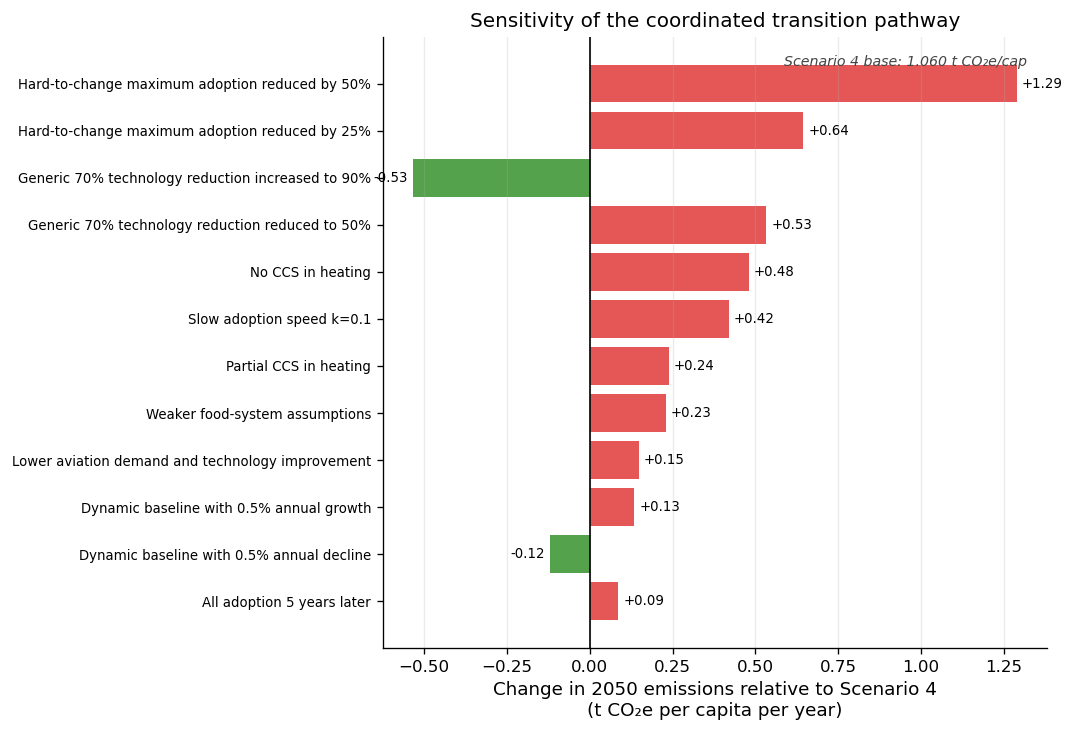

In [11]:
# Figure 5: sensitivity tornado
plot_df = (sensitivity_reference
    .query("variant_id != 'base'")
    .copy())
plot_df = (plot_df
    .reindex(plot_df['delta_2050_vs_base_tco2e_per_capita'].abs()
             .sort_values(ascending=False).index)
    .head(12)
    .iloc[::-1])

fig, ax = plt.subplots(figsize=(9, 6.2))
y = np.arange(len(plot_df))
deltas = plot_df['delta_2050_vs_base_tco2e_per_capita'].values
colors = ['#E45756' if d > 0 else '#54A24B' for d in deltas]
ax.barh(y, deltas, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['variant'], fontsize=8)
ax.set_xlabel('Change in 2050 emissions relative to Scenario 4\n(t CO₂e per capita per year)')
ax.set_title('Sensitivity of the coordinated transition pathway')
ax.grid(axis='x', alpha=0.25)
for i, d in enumerate(deltas):
    ha = 'left' if d >= 0 else 'right'
    offset = 0.015 if d >= 0 else -0.015
    ax.text(d + offset, i, f'{d:+.2f}', va='center', ha=ha, fontsize=8)

# Annotate base S4 value
base_row = sensitivity_reference.query("variant_id == 'base'")
if len(base_row):
    base_val = base_row['emissions_2050_tco2e_per_capita'].values[0]
    ax.text(0.97, 0.97, f'Scenario 4 base: {base_val:.3f} t CO₂e/cap',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            fontstyle='italic', color='#444444')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_sensitivity_tornado_2050.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'fig5_sensitivity_tornado_2050.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

### Supplementary: scenario coverage vs residual emissions

This figure visualises the relationship between the share of baseline emissions actively addressed by each scenario and the resulting 2050 residual emissions. The dashed line marks the 1.0 t target. Only near-complete coverage (Scenario 4, ~100%) approaches the target.

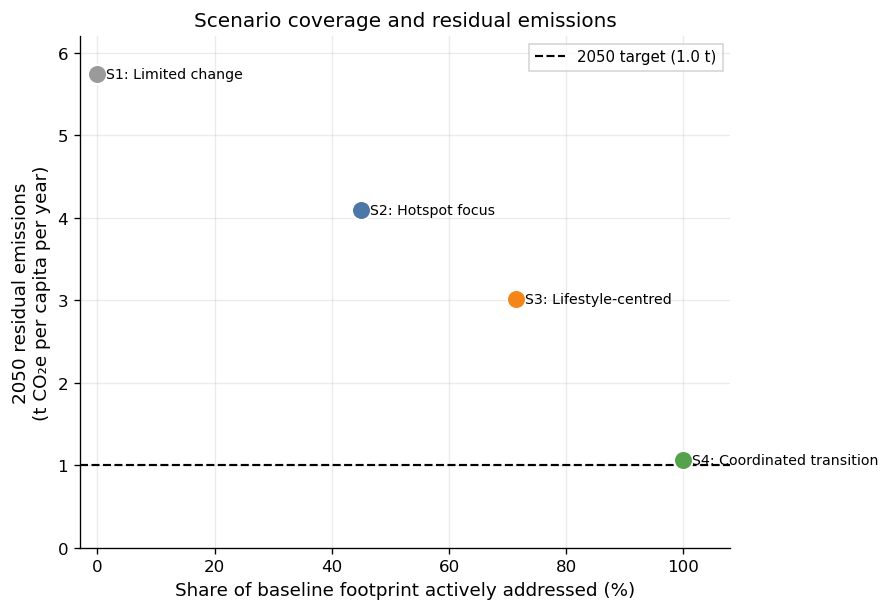

In [12]:
# Supplementary: coverage vs residual emissions
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for _, r in scenario_summary.iterrows():
    sid = r['scenario_id']
    ax.scatter(r['active_baseline_coverage_pct'], r['emissions_2050_tco2e_per_capita'],
               s=130, color=SCENARIO_COLORS[sid], edgecolor='white', linewidth=1.2, zorder=3)
    ax.text(r['active_baseline_coverage_pct'] + 1.5, r['emissions_2050_tco2e_per_capita'],
            SCENARIO_LABELS[sid], va='center', fontsize=8.5)

ax.axhline(TARGET_2050, color='black', linestyle='--', linewidth=1.3,
           label='2050 target (1.0 t)', zorder=2)
ax.set_xlim(-3, 108)
ax.set_ylim(0, 6.2)
ax.set_xlabel('Share of baseline footprint actively addressed (%)')
ax.set_ylabel('2050 residual emissions\n(t CO₂e per capita per year)')
ax.set_title('Scenario coverage and residual emissions')
ax.grid(alpha=0.25)
ax.legend(frameon=True, edgecolor='#cccccc', fancybox=False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'supp_coverage_vs_residual_emissions.png', bbox_inches='tight', pad_inches=0.12)
plt.savefig(FIG_DIR / 'supp_coverage_vs_residual_emissions.pdf', bbox_inches='tight', pad_inches=0.12)
plt.show()

## 7. Export regenerated tables

The notebook writes regenerated scenario and category results to `data/generated_from_notebook_*` files. These files are not needed for the article if the cleaned CSVs are already present, but they verify that the notebook reproduces the same outputs from the model equations alone.

In [13]:
scenario_results.to_csv(DATA_DIR / 'generated_from_notebook_scenario_results.csv', index=False)
category_results.to_csv(DATA_DIR / 'generated_from_notebook_category_results.csv', index=False)
print('Exported regenerated scenario and category results.')

Exported regenerated scenario and category results.


## 8. Key interpretation notes

- The baseline footprint (5.735 t CO₂e/capita) is **static** in the central model. No autonomous trends in income, prices or consumption volumes are modelled.
- **Scenario 4** is target-seeking and should not be read as a forecast. It defines the *boundary of the possible* under stated assumptions.
- The 2030 target used in the central analysis is 3.1 t CO₂e/capita/year; a 3.0 t interpretation is included in the sensitivity table.
- The choice of a **deterministic stress-test** design rests on three principles: transparency (outputs are exact functions of inputs), usability for municipalities, and replicability for other cities.
- **Adoption ceilings** (L) are more decisive for the 2050 gap than adoption speed (k) or timing (t₀). This asymmetry carries a direct governance interpretation: structural interventions that raise the share of population reached matter more for long-term target consistency than short-term acceleration measures.
- **Probabilistic uncertainty quantification** (Monte Carlo, scenario ensembles) is identified as future work. The deterministic OAT design is suited to the framework's purpose of identifying the most decisive assumptions for sufficiency.
- The main analytical result is the comparison between transition logics: hotspot-focused action, lifestyle-centred change and coordinated transition across lifestyle, infrastructure and technology.
- For the concept of the **urban consumption gap** and its role as a **sufficiency test** for city climate governance, see the manuscript Sections 2.2 and 2.3.